# 深度学习课程设计报告

## 一、封面

- 课程名称：  深度学习
- 设计题目：  低资源衡阳方言语音识别系统
- 姓    名：  吴彦蓓
- 学    号：  20234080111
- 班    级：  数据2301班
- 指导教师：  丁平尖
- 提交日期：  2026年6月29日

## 二、摘要

<!-- > 简述项目背景、解决的问题、采用的方法、主要结果（200–300字） -->

随着语音交互技术的发展，方言语音识别在医疗、公共服务等场景中具有一定应用价值。但衡阳方言属于低资源方言，公开语料较少，且存在发音差异明显、口语表达不规范等问题，传统普通话语音识别模型难以取得理想效果。本项目设计并实现了低资源衡阳方言语音识别系统，面向方言症状表达场景，自建衡阳方言语音数据集并完成录音、标注、清洗与划分。在方法上，系统采用 wav2vec2 预训练模型作为基础模型，通过 CTC 损失函数进行端到端微调，使模型能够从少量标注语音中学习衡阳方言的声学特征与文本映射关系。实验结果表明，经过方言数据微调后，模型在验证集上的字符错误率约为 0.12，识别效果明显优于未微调的通用模型，说明该方法在低资源方言语音识别任务中具有较好的适用性。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

<!-- > 说明选题来源、实际应用价值或科研意义 -->
随着语音识别技术的发展，语音交互已广泛应用于智能助手、公共服务等场景。但现有语音识别系统大多面向普通话或资源较丰富的语言，在方言场景下仍存在适配不足的问题。衡阳方言具有明显的地域发音特征，与普通话在声母、韵母、声调和口语表达方式上存在差异，同时公开可用的衡阳方言语音数据较少，属于典型的低资源语音识别任务。

本项目围绕低资源衡阳方言语音识别问题，设计并实现一个能够将衡阳方言语音自动转写为中文文本的语音识别系统。该系统面向方言语音输入场景，重点解决低资源条件下模型难以充分学习方言发音特征、普通话识别模型迁移效果有限等问题。该研究具有一定实际应用价值和科研意义：首先，本项目面向低资源衡阳方言语音识别场景，设计了可独立部署的语音识别系统，后续能够方便地接入智能体、语音助手或其他语音交互应用中，从而提升方言用户的使用体验，降低方言用户使用智能系统的门槛；其次，项目初步构建了衡阳方言语音数据集，并完成语音采集、文本标注和数据清洗，为后续相关研究提供了基础数据资源；此外，项目采用预训练语音模型微调的方式解决低资源方言语音识别问题，该方案具有一定迁移性，可为其他低资源方言的语音识别训练与应用提供参考。


### 3.2 问题描述

<!-- > 输入输出定义  
> 任务类型（分类/回归/检测/生成等）  
> 预期性能指标（准确率、mAP、BLEU、F1等） -->

本项目属于语音识别任务，目标是将输入的衡阳方言语音自动转写为对应的中文文本。该任务可以看作语音序列到文本序列的转写任务。

输入为经过预处理后的音频信号，统一采样率为 16kHz，内容主要包括日常表达、症状表达、功能句和信息补充句等衡阳方言语音。输出为该音频对应的中文字符序列，例如输入一段衡阳方言语音后，系统输出“我头有点痛”“喉咙不舒服”等文本结果。

在模型方法上，本项目采用 wav2vec2 预训练语音模型作为基础模型，并结合 CTC 损失函数进行微调。wav2vec2 可以从原始语音中提取声学特征，并通过 Transformer 结构建模上下文信息；CTC 损失适用于语音与文本没有逐帧对齐标注的情况，能够完成从语音序列到文本序列的端到端学习。

本任务的主要评价指标为字符错误率 CER（Character Error Rate）。CER 用于衡量模型转写文本与真实标注文本之间的差异，数值越低表示识别效果越好。预期目标是在验证集上将 CER 控制在 0.15 以内，使模型达到基本可用水平。若模型微调后 CER 明显低于未微调模型，说明预训练模型迁移到低资源衡阳方言场景是有效的。

## 四、数据集说明与预处理

### 4.1 数据来源与规模

<!-- >自建/公开数据集  
> 样本总量  
> 类别分布 -->
由于衡阳方言公开语音数据较少，难以直接使用现有公开数据集完成模型训练，因此本项目围绕衡阳方言语音识别任务自行构建数据集。考虑到实际应用场景，当前语料设计暂时面向就医与日常健康咨询场景。项目组织多名衡阳方言使用者进行录音，并完成音频切分、文本标注和数据整理。

语料文本包括单一症状词、单症状短句、双症状短句、病名或病症短句、功能句与信息补充句等类型。同时，为了便于不同说话人之间的识别效果对比，数据集中还加入了一部分公共句子，即多个说话人共同录制的相同文本内容。

音频数据由 3 名衡阳方言使用者录制，覆盖不同年龄和性别，包括 25 岁女性、62 岁女性和 68 岁男性。录音设备包括手机、耳麦和电脑录音设备，以增加数据来源的多样性。经过整理后，最终获得 4035 条有效语音样本，总时长约 3.08 小时。每条样本包含音频路径、对应文本和说话人编号三个字段，数据格式主要包括 path、sentence、speaker 三列。

从语料类别分布来看，数据集中公共句子约占 15%，单一症状词约占 5%，单症状短句约占 25%，双症状短句约占 25%，病名或病症短句约占 10%，非症状功能句与信息补充句约占 20%。

### 4.2 数据可视化与分析

<!-- > 样本示例 
> 统计分布 
> 相关性分析 -->



**数据加载与统计准备** <br>
读取标注表，解析全部音频时长并计算文本字符数。该单元是后续表格和图形的公共数据基础，运行后输出样本总量、累计时长和音频缺失数。


In [1]:
from pathlib import Path
import math
import re
import wave

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_DIR = Path.cwd() / "asr-experiments" / "wav2vec2"
DATA_PATH = PROJECT_DIR / "data" / "all.csv"

preferred_fonts = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
selected_font = next((font for font in preferred_fonts if font in installed_fonts), None)
if selected_font:
    plt.rcParams["font.sans-serif"] = [selected_font]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

def resolve_audio_path(raw_path):
    normalized = str(raw_path).replace("\\", "/")
    relative_path = normalized.split("/wav2vec2/", 1)[-1]
    return PROJECT_DIR / relative_path

def read_duration(audio_path):
    with wave.open(str(audio_path), "rb") as audio:
        return audio.getnframes() / audio.getframerate()

def infer_category(raw_path):
    parts = str(raw_path).replace("\\", "/").split("/")
    if "pub" in parts:
        return "公共句子"
    if any(part.startswith("B") for part in parts):
        return "单一症状词"
    if any(part.startswith("C") for part in parts):
        return "单症状短句"
    if any(part.startswith("D") for part in parts):
        return "双症状短句"
    if any(part.startswith("E") or part == "Fuke" for part in parts):
        return "病名/病症短句"
    if any(part.startswith("F") for part in parts):
        return "功能句/信息补充句"
    return "其他"

data = pd.read_csv(DATA_PATH)
data["audio_path"] = data["path"].map(resolve_audio_path)
missing_audio = int((~data["audio_path"].map(Path.exists)).sum())
if missing_audio:
    raise FileNotFoundError(f"存在 {missing_audio} 个缺失音频文件")
data["duration_seconds"] = data["audio_path"].map(read_duration)
data["text_length"] = data["sentence"].astype(str).map(lambda text: len(re.sub(r"\s+", "", text)))
data["category"] = data["path"].map(infer_category)

print(f"样本总量：{len(data):,} 条")
print(f"累计时长：{data['duration_seconds'].sum() / 3600:.3f} 小时")
print(f"缺失音频：{missing_audio} 条")


样本总量：4,035 条
累计时长：3.083 小时
缺失音频：0 条


**样本示例** <br>  
从公共句子、单症状短句、双症状短句和病名/病症短句中各选取一条样本，展示音频编号、文本标注、说话人和语料类别。

In [2]:
sample_rows = []
for category in ["公共句子", "单症状短句", "双症状短句", "病名/病症短句"]:
    group = data[data["category"] == category]
    if not group.empty:
        sample_rows.append(group.iloc[0])

sample_table = pd.DataFrame(sample_rows)
sample_table = pd.DataFrame({
    "文本标注": sample_table["sentence"],
    "说话人": sample_table["speaker"],
    "语料类别": sample_table["category"],
})
display(sample_table.style.hide(axis="index"))


文本标注,说话人,语料类别
体温升高,speaker_01,公共句子
明明不冷但总觉得发冷,speaker_01,单症状短句
这两天老是咳还觉得胸口发闷,speaker_01,双症状短句
最近像是着凉感冒了,speaker_01,病名/病症短句


**语料类别设计分布** <br> 
根据语料设计方案展示六类任务场景的目标占比。单症状和双症状短句是主体，功能句用于补充真实问诊中的时间、程度、部位、行为和求助信息。该图表示设计比例，而非将当前整理进训练集的目录覆盖误写为实测比例。


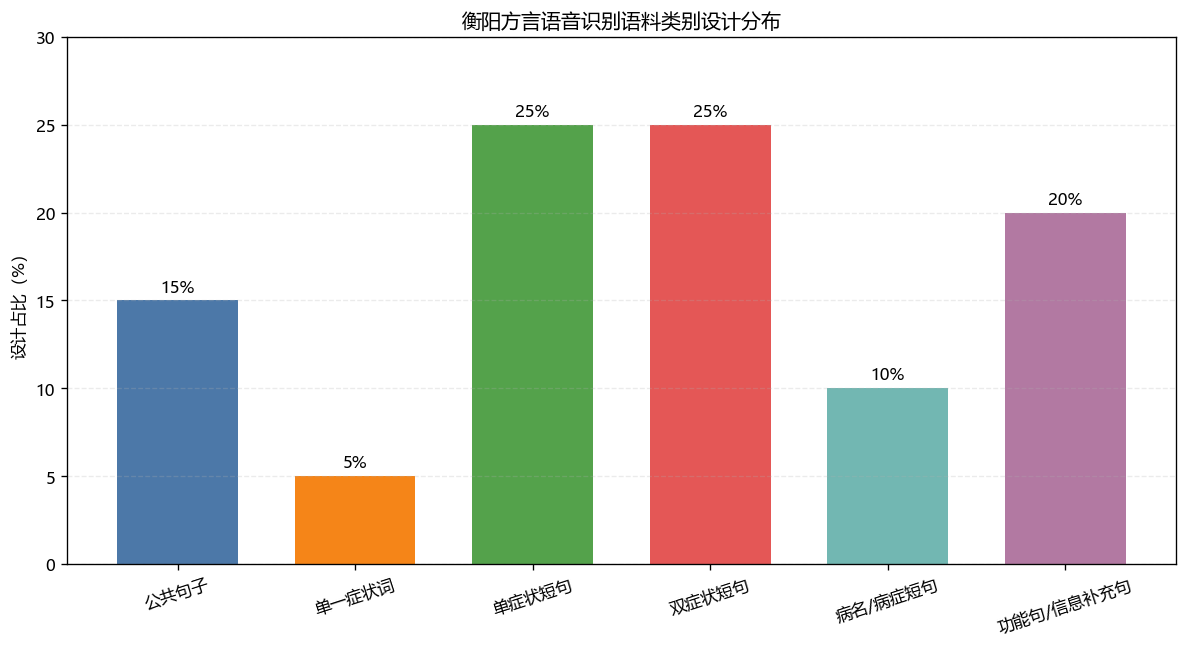

In [3]:
category_design = {
    "公共句子": 15,
    "单一症状词": 5,
    "单症状短句": 25,
    "双症状短句": 25,
    "病名/病症短句": 10,
    "功能句/信息补充句": 20,
}
colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#B279A2"]
fig, axis = plt.subplots(figsize=(10, 5.5))
bars = axis.bar(category_design.keys(), category_design.values(), color=colors, width=0.68)
axis.set(title="衡阳方言语音识别语料类别设计分布", ylabel="设计占比（%）", ylim=(0, 30))
axis.tick_params(axis="x", rotation=18)
axis.grid(axis="y", linestyle="--", alpha=0.25)
for bar, value in zip(bars, category_design.values()):
    axis.text(bar.get_x() + bar.get_width() / 2, value + 0.5, f"{value}%", ha="center")
plt.tight_layout()
plt.show()


**说话人样本分布** <br> 
统计三个匿名说话人的有效样本数和占比，用于判断说话人覆盖是否均衡。匿名化同时作用于 CSV 字段、路径和音频目录，因此图中不会出现原始身份标识。


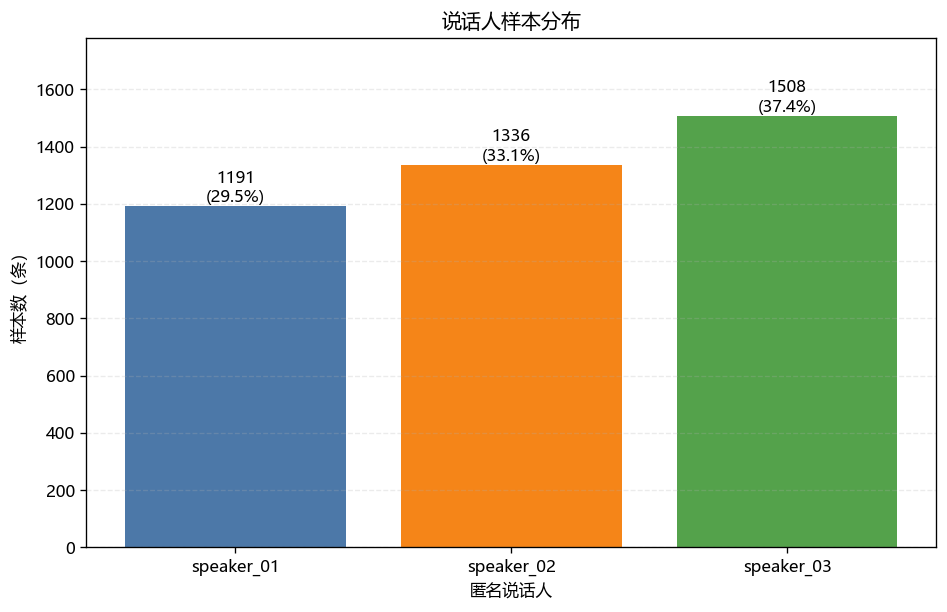

最大与最小样本数相差 317 条，整体分布较为均衡。


In [4]:
speaker_counts = data["speaker"].value_counts().sort_index()
fig, axis = plt.subplots(figsize=(8, 5.2))
bars = axis.bar(speaker_counts.index, speaker_counts.values, color=["#4C78A8", "#F58518", "#54A24B"])
axis.set(title="说话人样本分布", xlabel="匿名说话人", ylabel="样本数（条）")
axis.set_ylim(0, speaker_counts.max() * 1.18)
axis.grid(axis="y", linestyle="--", alpha=0.25)
for bar, value in zip(bars, speaker_counts.values):
    axis.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value}\n({value / len(data):.1%})",
        ha="center",
        va="bottom",
    )
plt.tight_layout()
plt.show()
print(f"最大与最小样本数相差 {speaker_counts.max() - speaker_counts.min()} 条，整体分布较为均衡。")


**音频时长分布**  <br>
将每条 WAV 音频划分为 0–2 秒、2–4 秒、4–6 秒和 6 秒以上四个区间。该统计用于说明数据是否以符合实际语音输入场景的短语音为主。


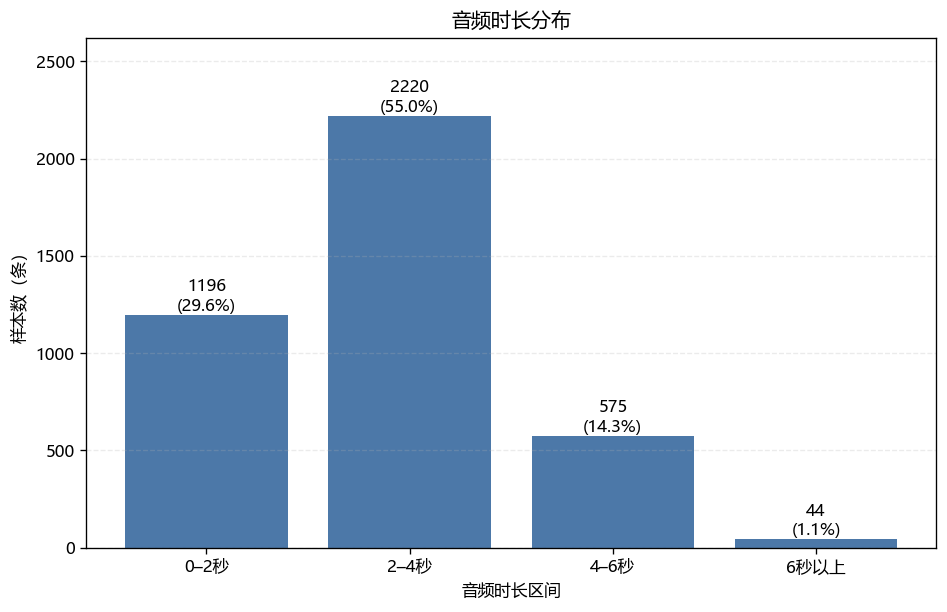

平均时长 2.75 秒，中位数 2.51 秒。
4 秒以内共 3,416 条，占 84.7%，数据以短语音为主。


In [5]:
duration_labels = ["0–2秒", "2–4秒", "4–6秒", "6秒以上"]
duration_bins = pd.cut(
    data["duration_seconds"],
    bins=[-math.inf, 2, 4, 6, math.inf],
    labels=duration_labels,
)
duration_counts = duration_bins.value_counts(sort=False)
fig, axis = plt.subplots(figsize=(8, 5.2))
bars = axis.bar(duration_labels, duration_counts.values, color="#4C78A8")
axis.set(title="音频时长分布", xlabel="音频时长区间", ylabel="样本数（条）")
axis.set_ylim(0, duration_counts.max() * 1.18)
axis.grid(axis="y", linestyle="--", alpha=0.25)
for bar, value in zip(bars, duration_counts.values):
    axis.text(bar.get_x() + bar.get_width() / 2, value, f"{value}\n({value / len(data):.1%})", ha="center", va="bottom")
plt.tight_layout()
plt.show()
short_audio_count = int(duration_counts["0–2秒"] + duration_counts["2–4秒"])
print(f"平均时长 {data['duration_seconds'].mean():.2f} 秒，中位数 {data['duration_seconds'].median():.2f} 秒。")
print(f"4 秒以内共 {short_audio_count:,} 条，占 {short_audio_count / len(data):.1%}，数据以短语音为主。")


**文本长度分布**  
按去除空白后的中文字符数划分文本区间。短文本占比较高，说明语料以症状词和短句为主，适合低资源条件下的字符级语音识别训练。


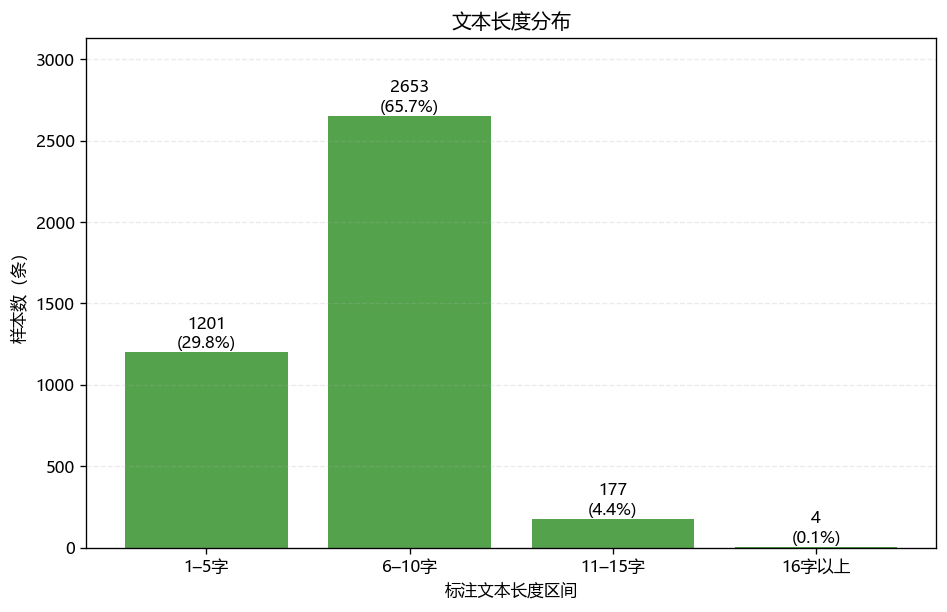

10 字以内共 3,854 条，占 95.5%，文本整体以短句为主。


In [6]:
text_labels = ["1–5字", "6–10字", "11–15字", "16字以上"]
text_bins = pd.cut(data["text_length"], bins=[0, 5, 10, 15, math.inf], labels=text_labels)
text_counts = text_bins.value_counts(sort=False)
fig, axis = plt.subplots(figsize=(8, 5.2))
bars = axis.bar(text_labels, text_counts.values, color="#54A24B")
axis.set(title="文本长度分布", xlabel="标注文本长度区间", ylabel="样本数（条）")
axis.set_ylim(0, text_counts.max() * 1.18)
axis.grid(axis="y", linestyle="--", alpha=0.25)
for bar, value in zip(bars, text_counts.values):
    axis.text(bar.get_x() + bar.get_width() / 2, value, f"{value}\n({value / len(data):.1%})", ha="center", va="bottom")
plt.tight_layout()
plt.show()
short_text_count = int(text_counts["1–5字"] + text_counts["6–10字"])
print(f"10 字以内共 {short_text_count:,} 条，占 {short_text_count / len(data):.1%}，文本整体以短句为主。")


**音频时长与文本长度相关性**  <br>
使用散点图和线性趋势线分析文本长度与音频时长的关系，并计算 Pearson 相关系数。不同颜色代表匿名说话人，用于观察同等文本长度下的语速差异。


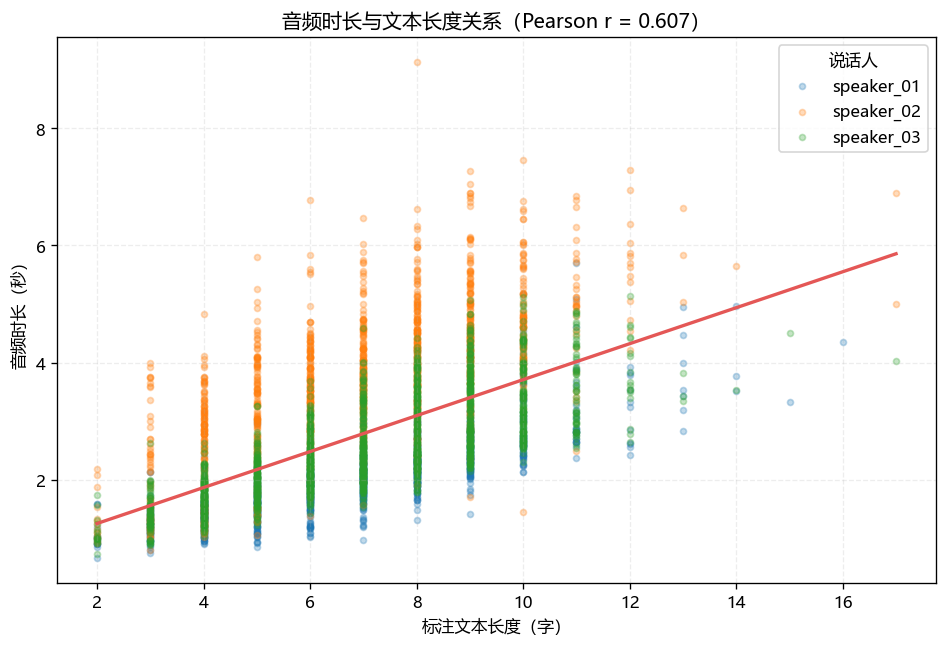

Pearson 相关系数为 0.607，音频时长与文本长度呈中等程度正相关。
文本越长，音频通常越长；但说话人语速、停顿习惯和录音切分会造成同等文本长度下的时长差异。


In [7]:
correlation = data["text_length"].corr(data["duration_seconds"])
coefficients = np.polyfit(data["text_length"], data["duration_seconds"], 1)
x_values = np.linspace(data["text_length"].min(), data["text_length"].max(), 100)

fig, axis = plt.subplots(figsize=(8, 5.5))
for speaker, group in data.groupby("speaker"):
    axis.scatter(group["text_length"], group["duration_seconds"], s=13, alpha=0.28, label=speaker)
axis.plot(x_values, np.polyval(coefficients, x_values), color="#E45756", linewidth=2)
axis.set(
    title=f"音频时长与文本长度关系（Pearson r = {correlation:.3f}）",
    xlabel="标注文本长度（字）",
    ylabel="音频时长（秒）",
)
axis.legend(title="说话人")
axis.grid(linestyle="--", alpha=0.22)
plt.tight_layout()
plt.show()
print(f"Pearson 相关系数为 {correlation:.3f}，音频时长与文本长度呈中等程度正相关。")
print("文本越长，音频通常越长；但说话人语速、停顿习惯和录音切分会造成同等文本长度下的时长差异。")


**结论** <br>  
当前数据集包含 4,035 条有效样本，累计约 3.08 小时。三个说话人的样本占比分别约为 29.5%、33.1% 和 37.4%，整体较为均衡；约 84.7% 的音频不超过 4 秒，约 95.5% 的文本不超过 10 字，说明数据以短语音、短文本为主。音频时长与文本长度的 Pearson 相关系数约为 0.607，二者呈中等程度正相关，但同时保留了不同说话人的真实语速差异。


### 4.3 预处理流程

<!-- > 清洗  
> 标注  
> 归一化  
> 数据增强  
> 训练/验证/测试集划分 -->

为保证自建衡阳方言语音数据能够满足模型训练要求，本实验对音频数据进行了统一预处理。整体流程包括数据对齐、文本清洗、音频格式统一、标签编码以及数据集划分。

首先，对原始语音文件和转写文本进行整理。原始语音文件为整段文本对应的连续音频，实验使用 Audacity 音频处理软件根据语音间隔对原始音频进行自动切片，并在切片后进行人工核对。随后，根据音频文件名的自然顺序读取 wav 文件，并与对应的文本标注逐条对齐，生成统一的数据索引文件。每条数据包含音频路径、文本标注以及说话人编号等信息，便于后续训练脚本批量读取。经过整理后，共获得 4035 条有效语音样本。

在文本预处理方面，首先去除标注文本中行首编号、换行符和多余空格，然后进一步过滤标点符号及特殊字符，仅保留模型需要学习的主要中文字符内容。这样可以减少无关符号对识别结果的干扰，使模型的学习目标更加集中于衡阳方言语音到中文字符序列的映射关系。

在音频预处理方面，实验统一采用 16kHz 采样率和单声道音频作为模型输入格式。经检查，当前数据集中 4035 条语音样本均为 16kHz 单声道音频。同时，在训练脚本中仍设置了重采样逻辑作为兜底处理，当读取到采样率不一致的音频时，可自动重采样至 16kHz，从而保证输入数据格式的一致性。随后，使用 Wav2Vec2FeatureExtractor 对原始音频波形进行归一化处理，并转换为模型可接收的 input_values 输入。

在标签编码方面，实验根据训练集和验证集中的文本内容构建字符级词表。由于本任务采用 CTC 训练方式，因此将中文字符作为基本建模单元，并将空格映射为 CTC 分隔符“|”，同时加入 [UNK] 和 [PAD] 等特殊标记。之后，利用 Wav2Vec2CTCTokenizer 将文本标注转换为对应的标签序列 labels，用于模型训练时计算 CTC 损失。

最后，对整理后的数据进行随机打乱，并按照 9:1 的比例划分训练集和验证集。其中，训练集包含 3631 条样本，验证集包含 404 条样本。通过上述预处理流程，原始衡阳方言语音数据被统一转换为包含 input_values 和 labels 的模型训练数据，为后续 Wav2Vec2-CTC 模型微调提供了规范的数据基础。


## 五、模型设计与选择

### 5.1 基准模型（Baseline）

**MFCC + BiLSTM + CTC**：该模型为传统端到端语音识别基线。首先从音频中提取 MFCC 声学特征，用于表示语音信号的短时频谱信息；然后利用双向 LSTM 建模语音帧之间的上下文关系；最后通过全连接层输出字符类别概率，并采用 CTC Loss 解决语音帧序列与文本字符序列长度不一致、难以逐帧对齐的问题。

**Dolphin-small**：dolphin-small[1] 模型是面向东方语种的大规模多语言语音识别模型，支持包括普通话及多种中文方言（包含湖南方言）在内的多语种语音识别任务。其训练数据规模超过 21 万小时，并通过引入语言与区域标记机制增强对不同方言差异的建模能力。

[1] Y. Meng et al., “Dolphin: A Large-Scale Automatic Speech Recognition Model for Eastern Languages,” arXiv.org, 2025. https://arxiv.org/abs/2503.20212

### 5.2 最终模型架构

针对衡阳方言语料规模有限、口语表达不规范以及与普通话存在发音差异等问题，本系统采用 Alexei Baevski 等人提出的基于 wav2vec 2.0 架构的跨语种预训练模型 `facebook/wav2vec2-large-xlsr-53` [2] 进行迁移微调，在通用语音表征能力基础上完成衡阳方言医疗场景适配。

wav2vec 2.0 通过自监督学习从未标注语音中学习通用语音特征表示，再利用少量标注数据进行微调，从而在低资源语音识别任务中仍能保持较好的识别性能。因此，该模型特别适用于衡阳方言这类标注数据有限的场景。

在模型结构上，本系统基于 wav2vec 2.0 预训练编码器构建端到端语音识别模型。输入语音信号首先经过卷积特征编码器提取低层声学特征，并通过 Transformer 上下文网络进行时序建模，得到高层语音表示；随后接入一层线性分类头（Linear Projection），将连续语音表示映射到字符级词表空间。

训练阶段采用 CTC（Connectionist Temporal Classification）目标函数 [3]，在无显式音素级对齐标注的条件下学习语音-文本映射，其定义为：

$$
L_{CTC} = -\log P(y|x)
= -\log \sum_{\pi \in B^{-1}(y)} \prod_{t=1}^{T} p_t(\pi_t)
$$

其中，$\pi$ 表示所有可能的对齐路径，$B$ 为去重与去 blank 操作。该目标函数通过对所有可能对齐路径求和，使模型在无需显式对齐信息的情况下完成序列学习。

推理阶段通过贪心解码输出最终文本序列，其过程为：

$$
\hat{\pi}_t = \arg\max_k p_t(k)
$$

$$
\hat{y} = B(\hat{\pi}_{1:T})
$$

即逐帧选择概率最大的标签，并通过 CTC 折叠规则得到最终转写结果。

该结构无需显式音素级对齐信息，即可完成从语音到文本的端到端建模，降低了对标注数据的依赖，适用于方言语音识别这一低资源场景。在此基础上，系统通过对预训练模型进行微调，使其从通用语音建模能力进一步适配到衡阳方言医疗表达识别任务，从而为后续症状抽取与导诊决策提供稳定可靠的文本输入。

![基于 wav2vec2 的方言语音识别模型结构](./image.png)

<center>基于 wav2vec2 的方言语音识别模型结构</center>

实验中使用 RTX 4090 单卡进行训练，单卡批大小设置为 8，梯度累积步数为 2，因此等效批大小为 16。训练过程中启用 FP16 混合精度，并采用按长度分组（group_by_length=True）的方式组织 batch，以降低显存占用并减少无效填充计算。本次最优实验学习率设置为 1e-5，模型训练至约 11300 step 时验证集指标达到较优水平，对应约 49.78 个 epoch，验证集 CER 降至约 0.122。结构设置上，默认冻结 wav2vec2 前端声学特征提取层，仅微调上层上下文表示模块和 CTC 分类头，从而在低资源数据条件下降低过拟合风险。模型按 epoch 保存，并通过限制检查点保留数量控制存储开销。

[2] A. Baevski, H. Zhou, A. Mohamed, and M. Auli, “wav2vec 2.0: A Framework for Self-Supervised Learning of Speech Representations,” arXiv.org, 2020. https://arxiv.org/abs/2006.11477v3 (accessed Jul. 29, 2025).

[3] A. Graves, S. Fernández, F. Gomez, and J. Schmidhuber, “Connectionist temporal classification,” Proceedings of the 23rd international conference on Machine learning - ICML ’06, 2006, doi: https://doi.org/10.1145/1143844.1143891.



## 六、实验与结果分析

### 6.1 实验环境
<!-- 
- 硬件：CPU/GPU型号、内存  
- 软件：Python版本、深度学习框架、主要库 -->

本实验在 AutoDL 云端 GPU 实例上完成模型训练与测试。硬件方面，实验平台配备 1 张 NVIDIA RTX 4090 GPU，显存容量为 24GB；CPU 为 16 vCPU Intel(R) Xeon(R) Gold 6430；系统内存为 120GB。存储方面，实验环境包含 30GB 系统盘和 50GB SSD 数据盘，用于存放训练代码、语音数据、模型权重及实验日志。

软件环境方面，实验采用 huggingface/transformers/i1:v1 镜像作为基础运行环境，Python 版本为 3.8.10，深度学习框架为 PyTorch 2.4.1，CUDA 版本为 12.1。模型训练主要基于 Hugging Face Transformers 库实现，使用 Wav2Vec2 相关组件完成音频特征提取、字符级标签编码和 CTC 微调。同时，实验使用 Datasets 库进行数据集读取与处理，使用 Torchaudio 进行音频读取与处理，并使用 Evaluate 库计算模型识别评价指标。

### 6.2 评价指标

<!-- - 根据任务列出具体指标及计算方式 -->

在语音识别模块中，本实验采用字符错误率（Character Error Rate, CER）作为核心评价指标，用于衡量模型识别文本与人工标注文本之间的字符级差异。由于本任务的输出结果为中文字符序列，且衡阳方言语音识别更关注转写文本与真实标注之间的字符匹配程度，因此 CER 能够较好地反映模型的识别效果。计算公式如下：

$$
CER = \frac{S + D + I}{N}
$$

其中，$S$ 表示替换错误的字符数，$D$ 表示删除错误的字符数，$I$ 表示插入错误的字符数，$N$ 表示参考文本中的字符总数。该指标取值越小，说明模型识别结果与人工标注文本越接近，语音识别效果越好。




### 6.3 超参数设置与调优

<!-- - 调参方法
- 有效调参记录 -->

模型训练过程中重点探索了解冻层数与时间掩码概率两个关键参数的取值。前者决定微调阶段允许更新的高层表示容量，后者决定训练中时间维扰动强度，二者分别影响模型的可学习自由度与鲁棒性约束强度。

具体而言，解冻层数参数记为 n。在保持底层声学特征提取部分冻结的前提下，仅解冻顶部若干层编码器参与反向更新；n 越大，模型对目标域（方言口语）适配能力越强，但也更容易放大噪声并增加训练不稳定性。时间掩码概率参数记为 m，对应训练中对时间帧进行掩蔽的数据增强强度；m 较小时增强偏弱，泛化提升有限，m 过大则可能导致有效语音信息被过度破坏。基于该思路，实验采用网格搜索n∈{6,8,10}，m∈{0.05,0.10}。最终结果如图所示，颜色越深代表模型效果越好。


![网格搜索结果](./image2.png)

<center>网格搜索结果</center>

从结果可见，增加解冻层数带来的收益显著，高层可训练参数更多时，模型对方言发音差异和语境变体的适配能力更好；同时，适度提高时间掩码概率至0.10可进一步提升泛化效果，说明在当前数据规模下，较强时间扰动有助于抑制过拟合并增强鲁棒性。最终系统选择 n=10,m=0.10 作为部署配置。该组合在日志曲线上也表现出更稳定的收敛趋势，且最终验证误差最低，与离线预测对比结果一致。


**详细对比**  
以下表格和曲线直接读取已有调参与预测结果汇总文件，展示不同候选配置在验证集上的表现差异。

,配置名称,样本数,平均CER,中位CER,加权CER,完全匹配率,平均文本长度
0,n10m10,404,0.1181,0.0000,0.1225,0.5297,6.9332
1,n10m05,404,0.1298,0.0909,0.1367,0.4901,6.9332
2,n8m10,404,0.1322,0.0000,0.1399,0.5050,6.9332
3,n8m05,404,0.1345,0.1000,0.1428,0.4728,6.9332
4,n6m05,404,0.1604,0.1111,0.1657,0.4455,6.9332


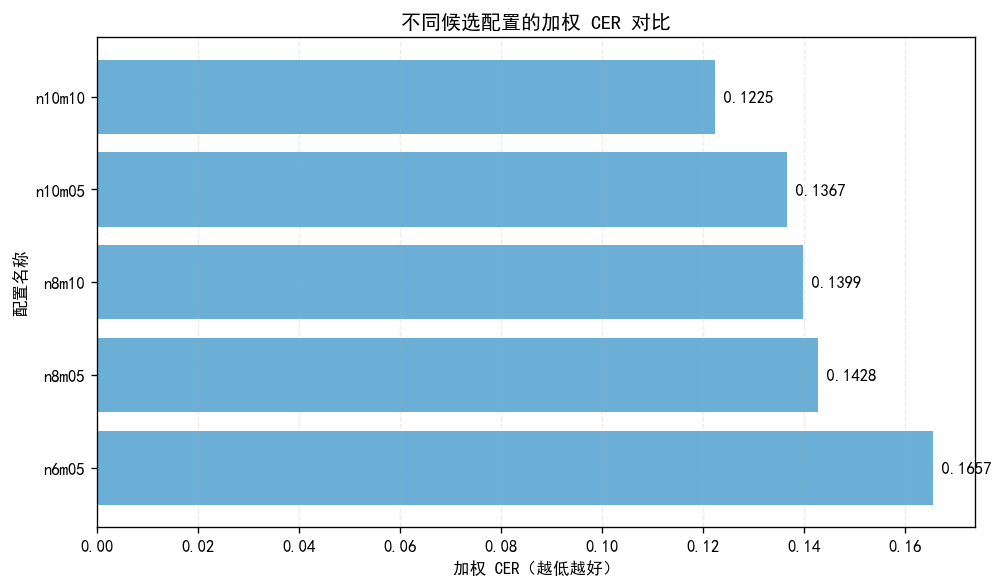

最优配置为 n10m10，加权 CER=0.1225，完全匹配率=53.0%。


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

PROJECT_DIR = Path.cwd()
grid_metrics_path = PROJECT_DIR / "asr-experiments" / "优化过程" / "analysis_output" / "table_grid_search_metrics.csv"
grid_metrics = pd.read_csv(grid_metrics_path).sort_values("weighted_cer_by_len").reset_index(drop=True)
best_grid = grid_metrics.iloc[0]

grid_display = grid_metrics.copy()
rename_map = {
    "name": "配置名称",
    "samples": "样本数",
    "mean_cer": "平均CER",
    "median_cer": "中位CER",
    "weighted_cer_by_len": "加权CER",
    "exact_match_rate": "完全匹配率",
    "mean_len": "平均文本长度",
}
grid_display = grid_display.rename(columns=rename_map)[list(rename_map.values())]
for column in ["平均CER", "中位CER", "加权CER", "完全匹配率", "平均文本长度"]:
    grid_display[column] = grid_display[column].map(lambda value: f"{value:.4f}")
display(grid_display)

fig, axis = plt.subplots(figsize=(8.5, 5))
bar_data = grid_metrics.sort_values("weighted_cer_by_len", ascending=False)
bars = axis.barh(bar_data["name"], bar_data["weighted_cer_by_len"], color="#6baed6")
axis.set_title("不同候选配置的加权 CER 对比")
axis.set_xlabel("加权 CER（越低越好）")
axis.set_ylabel("配置名称")
axis.grid(axis="x", alpha=0.25, linestyle="--")
for bar, value in zip(bars, bar_data["weighted_cer_by_len"]):
    axis.text(value, bar.get_y() + bar.get_height() / 2, f" {value:.4f}", va="center")
plt.tight_layout()
plt.show()

print(f"最优配置为 {best_grid['name']}，加权 CER={best_grid['weighted_cer_by_len']:.4f}，完全匹配率={best_grid['exact_match_rate']:.1%}。")

### 6.4 主要实验结果

<!-- > 结果全部在ipynb中展示（不要截图，直接代码调用生成） 
- 表格与曲线（损失曲线、精度曲线） 
- 不同模型/方法的对比结果 -->

本节主要包括：（1）本模型微调过程中的训练损失、验证损失和验证 CER 曲线；（2）对比实验结果与分析。

**读取实验结果**  
从本地训练日志和基线结果文件中读取数据。

In [9]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

PROJECT_DIR = Path.cwd()
ASR_DIR = PROJECT_DIR / "asr-experiments"
ANALYSIS_DIR = ASR_DIR / "优化过程" / "analysis_output"

trainer_state_path = ASR_DIR / "checkpoint-11300" / "trainer_state.json"
train_loss_path = ANALYSIS_DIR / "table_train_loss_points_from_trainer_state.csv"
eval_curve_path = ANALYSIS_DIR / "table_eval_curve_points_from_trainer_state.csv"
grid_metrics_path = ANALYSIS_DIR / "table_grid_search_metrics.csv"

mfcc_summary_path = ASR_DIR / "wav2vec2" / "baseline_results" / "baseline_summary.json"
mfcc_predictions_path = ASR_DIR / "wav2vec2" / "baseline_results" / "baseline_predictions.csv"
dolphin_summary_path = ASR_DIR / "dolphin-ft" / "valid" / "results" / "summary_dolphin_valid.json"

with trainer_state_path.open("r", encoding="utf-8") as file:
    trainer_state = json.load(file)

train_loss = pd.read_csv(train_loss_path)
eval_curve = pd.read_csv(eval_curve_path)
grid_metrics = pd.read_csv(grid_metrics_path).sort_values("weighted_cer_by_len").reset_index(drop=True)

with mfcc_summary_path.open("r", encoding="utf-8") as file:
    mfcc_summary = json.load(file)
with dolphin_summary_path.open("r", encoding="utf-8") as file:
    dolphin_summary = json.load(file)

mfcc_predictions = pd.read_csv(mfcc_predictions_path)
mfcc_cer = mfcc_predictions["CER"].astype(float)

best_eval = eval_curve.loc[eval_curve["eval_cer"].idxmin()]
final_eval = eval_curve.loc[eval_curve["step"].idxmax()]
best_grid = grid_metrics.iloc[0]

print(f"训练日志步数: {trainer_state.get('global_step')} step")
print(f"最终日志 epoch: {trainer_state.get('epoch'):.2f}")
print(f"验证曲线最低 CER: {best_eval['eval_cer']:.4f}，step={int(best_eval['step'])}")
print(f"最终 checkpoint CER: {final_eval['eval_cer']:.4f}，step={int(final_eval['step'])}")

训练日志步数: 11300 step
最终日志 epoch: 49.78
验证曲线最低 CER: 0.1210，step=10800
最终 checkpoint CER: 0.1225，step=11300


**展示对比结果**  

In [9]:
result_rows = [
    {
        "模型/方法": "MFCC + BiLSTM + CTC",
        "平均CER": mfcc_summary["final"]["mean_cer"],
        "加权CER": mfcc_summary["final"]["weighted_cer"],
        "中位CER": mfcc_cer.median(),
        "完全匹配率": (mfcc_cer == 0).mean(),
    },
    {
        "模型/方法": "Dolphin-small",
        "平均CER": dolphin_summary["mean_cer"],
        "加权CER": dolphin_summary["mean_cer"],
        "中位CER": dolphin_summary["median_cer"],
        "完全匹配率": dolphin_summary["cer_eq_0"],
    },
    {
        "模型/方法": "本文模型",
        "平均CER": best_grid["mean_cer"],
        "加权CER": best_grid["weighted_cer_by_len"],
        "中位CER": best_grid["median_cer"],
        "完全匹配率": best_grid["exact_match_rate"],
    },
]

result_table = pd.DataFrame(result_rows)
format_table = result_table.copy()
for column in ["平均CER", "加权CER", "中位CER", "完全匹配率"]:
    format_table[column] = format_table[column].map(lambda value: f"{value:.4f}")

display(format_table)

mfcc_reduction = 1 - best_grid["weighted_cer_by_len"] / mfcc_summary["final"]["weighted_cer"]
dolphin_reduction = 1 - best_grid["weighted_cer_by_len"] / dolphin_summary["mean_cer"]

,模型/方法,平均CER,加权CER,中位CER,完全匹配率
0,MFCC + BiLSTM + CTC,0.9401,0.9400,1.0000,0.0025
1,Dolphin-small,0.3350,0.3350,0.2727,0.2153
2,本文模型,0.1181,0.1225,0.0000,0.5297


三组实验评价指标统一采用字符错误率（CER）。为保证对比公平性，实验中保持相同的数据划分与评测口径，即三组模型均基于同一批验证语音与标注文本进行预测，并对生成结果按照统一公式计算平均 CER、加权 CER、中位 CER 及完全匹配率，从而保证结果具有可比性。

如表所示，本文模型在各项评价指标上均优于对比方法。与 Dolphin-small 模型相比，本文模型的平均 CER 从 0.3350 降至 0.1181，识别误差显著降低，同时中位 CER 为 0，说明在多数样本上能够实现稳定且准确的识别效果。

相较于 MFCC + BiLSTM + CTC 模型，本文模型在衡阳方言数据上的性能提升更加明显，平均 CER 由 0.9401 大幅下降至 0.1181，加权 CER 也由 0.9400 降至 0.1225，表明传统声学特征结合循环神经网络的方法在低资源方言语音识别任务中表现有限，而基于大规模预训练模型进行迁移微调能够显著提升模型对特定发音特征的建模能力。

从分布指标来看，本文模型的完全匹配率达到 0.5297，明显高于 MFCC + BiLSTM + CTC 模型的 0.0025 和 Dolphin-small 模型的 0.2153，说明超过一半的语音样本能够实现完全正确识别。同时，该模型的中位 CER 为 0.0000，进一步体现了模型在多数样本上的稳定表现。

综合来看，本文模型在识别准确性与稳定性方面均表现出较优性能，验证了技术路线在低资源语音识别任务中的有效性。同时，相较于传统端到端语音识别模型和通用中文语音识别模型，针对具体方言场景进行定制化微调仍具有明显优势。

以下柱状图对比不同模型或方法的 CER 与完全匹配率。左图中柱子越低越好，右图中柱子越高越好。

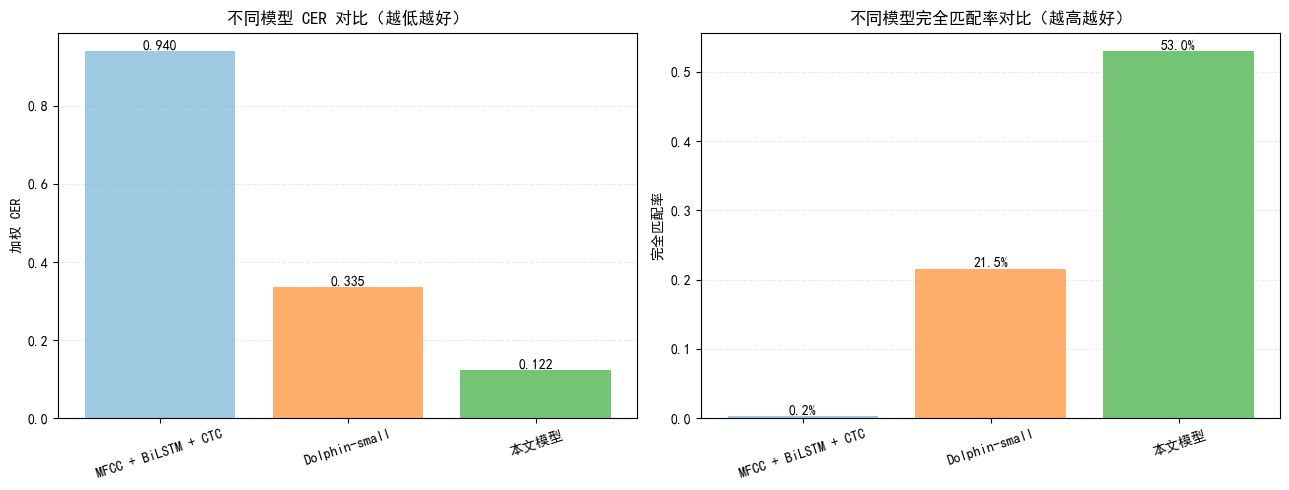

In [15]:

comparison = result_table[["模型/方法", "平均CER", "加权CER", "完全匹配率"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(comparison["模型/方法"], comparison["加权CER"], color=["#9ecae1", "#fdae6b", "#74c476"])
axes[0].set_title("不同模型 CER 对比（越低越好）")
axes[0].set_ylabel("加权 CER")
axes[0].tick_params(axis="x", rotation=18)
axes[0].grid(axis="y", alpha=0.25, linestyle="--")
for bar, value in zip(bars, comparison["加权CER"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value, f"{value:.3f}", ha="center", va="bottom")

bars = axes[1].bar(comparison["模型/方法"], comparison["完全匹配率"], color=["#9ecae1", "#fdae6b", "#74c476"])
axes[1].set_title("不同模型完全匹配率对比（越高越好）")
axes[1].set_ylabel("完全匹配率")
axes[1].tick_params(axis="x", rotation=18)
axes[1].grid(axis="y", alpha=0.25, linestyle="--")
for bar, value in zip(bars, comparison["完全匹配率"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, value, f"{value:.1%}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

**训练损失曲线**  

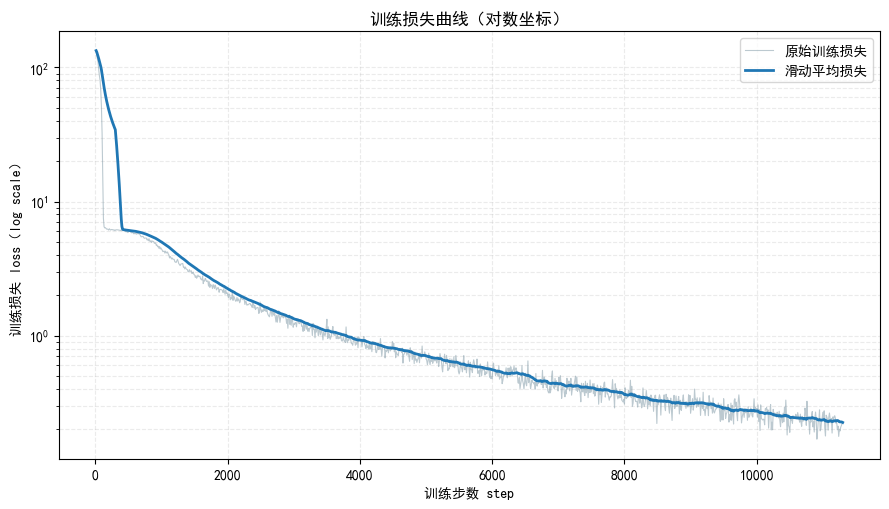

训练损失由初期约 133.46 下降到最终约 0.2282。


In [14]:
train_plot = train_loss.copy()
train_plot["loss_smooth"] = train_plot["loss"].rolling(window=30, min_periods=1).mean()

fig, axis = plt.subplots(figsize=(9, 5.2))
axis.plot(
    train_plot["step"],
    train_plot["loss"],
    color="#6b8998",
    linewidth=0.8,
    alpha=0.45,
    label="原始训练损失",
)
axis.plot(
    train_plot["step"],
    train_plot["loss_smooth"],
    color="#1f77b4",
    linewidth=2.0,
    label="滑动平均损失",
)

axis.set_yscale("log")  # 使用对数坐标，避免前期极大 loss 压扁后期变化
axis.set_title("训练损失曲线（对数坐标）")
axis.set_xlabel("训练步数 step")
axis.set_ylabel("训练损失 loss（log scale）")
axis.grid(alpha=0.25, linestyle="--", which="both")
axis.legend()

plt.tight_layout()
plt.show()

print(
    f"训练损失由初期约 {train_plot['loss'].iloc[0]:.2f} "
    f"下降到最终约 {train_plot['loss'].iloc[-1]:.4f}。"
)

从曲线可以看出，模型在训练初期损失值较高，随后迅速下降，说明模型能够较快学习到衡阳方言语音与文本标注之间的对应关系。随着训练步数增加，损失下降速度逐渐减缓，并在后期趋于平稳，表明模型训练过程整体收敛。

由于训练初期损失值明显高于后期，为避免前期极大值压缩后期曲线变化，图中采用对数坐标展示训练损失，并同时绘制原始训练损失与滑动平均损失，以更清晰地反映模型收敛趋势。

**验证集曲线**  

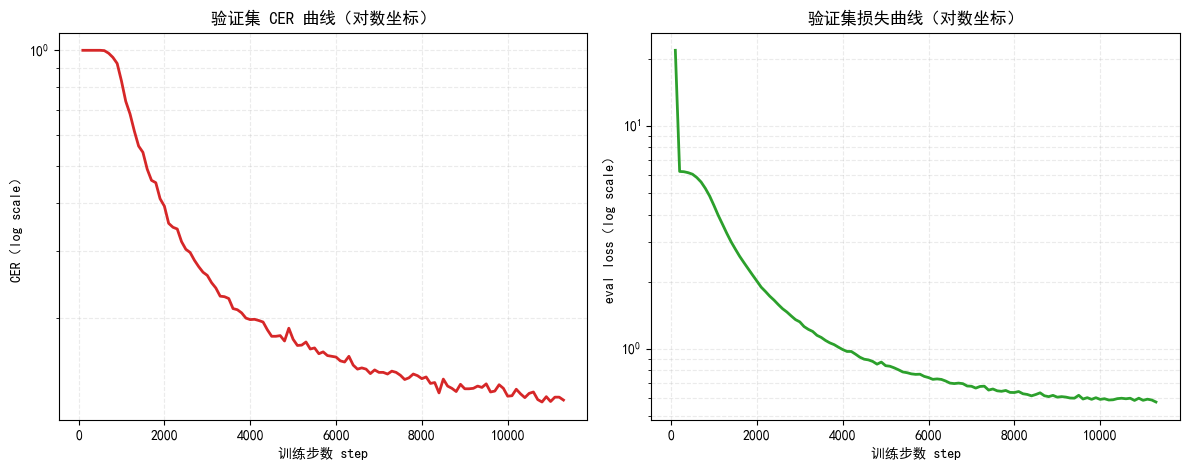

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# 验证集 CER 曲线
axes[0].plot(eval_curve["step"], eval_curve["eval_cer"], color="#d62728", linewidth=2)
axes[0].set_yscale("log")
axes[0].set_title("验证集 CER 曲线（对数坐标）")
axes[0].set_xlabel("训练步数 step")
axes[0].set_ylabel("CER（log scale）")
axes[0].grid(alpha=0.25, linestyle="--", which="both")

# 验证集损失曲线
axes[1].plot(eval_curve["step"], eval_curve["eval_loss"], color="#2ca02c", linewidth=2)
axes[1].set_yscale("log")
axes[1].set_title("验证集损失曲线（对数坐标）")
axes[1].set_xlabel("训练步数 step")
axes[1].set_ylabel("eval loss（log scale）")
axes[1].grid(alpha=0.25, linestyle="--", which="both")

plt.tight_layout()
plt.show()

从曲线可以看出，随训练步数增加，两个指标均呈明显下降趋势，说明模型在训练过程中逐渐学习到衡阳方言语音与文本之间的映射关系。训练前期 CER 和 loss 下降较快，表明模型快速完成了对任务的初步适配；训练后期下降速度减缓并逐渐趋于稳定，说明模型性能逐步收敛。同时，验证集损失未出现明显反弹，说明模型没有出现明显过拟合现象，具有较好的泛化能力。

### 6.5 可视化分析

针对语音识别任务，本节主要进行以下可视化分析：（1）展示语音波形与梅尔频谱，观察输入语音的时域和频域特征；（2）展示验证集 CER 分布，分析整体识别误差分布情况；（3）结合高错误样本和字符级错误统计，分析模型在衡阳方言医疗短句识别中的主要错误来源。

**读取预测结果与音频工具函数**  

In [20]:
from collections import Counter
from pathlib import Path
import wave

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

PROJECT_DIR = Path.cwd()
VALID_CSV = PROJECT_DIR / "asr-experiments" / "wav2vec2" / "data" / "valid.csv"
PREDICTIONS_CSV = PROJECT_DIR / "asr-experiments" / "predictions.csv"

valid_df = pd.read_csv(VALID_CSV)
predictions_df = pd.read_csv(PREDICTIONS_CSV)
predictions_df["CER"] = predictions_df["CER"].astype(float)
predictions_df["LEN"] = predictions_df["LEN"].astype(int)


def resolve_audio_path(raw_path):
    path = Path(str(raw_path).replace("\\", "/"))
    if path.is_absolute():
        return path
    return PROJECT_DIR / path


def read_wav_mono(path):
    path = Path(path)
    with wave.open(str(path), "rb") as wav_file:
        sample_rate = wav_file.getframerate()
        channels = wav_file.getnchannels()
        sample_width = wav_file.getsampwidth()
        frames = wav_file.readframes(wav_file.getnframes())

    if sample_width == 1:
        audio = np.frombuffer(frames, dtype=np.uint8).astype(np.float32)
        audio = (audio - 128.0) / 128.0
    elif sample_width == 2:
        audio = np.frombuffer(frames, dtype=np.int16).astype(np.float32) / 32768.0
    elif sample_width == 4:
        audio = np.frombuffer(frames, dtype=np.int32).astype(np.float32) / 2147483648.0
    else:
        raise ValueError(f"不支持的采样宽度: {sample_width}")

    if channels > 1:
        audio = audio.reshape(-1, channels).mean(axis=1)
    return audio, sample_rate


def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)


def mel_to_hz(mel):
    return 700.0 * (10 ** (mel / 2595.0) - 1.0)


def mel_filterbank(sample_rate, n_fft=512, n_mels=80, fmin=0.0, fmax=None):
    fmax = fmax or sample_rate / 2
    mel_points = np.linspace(hz_to_mel(fmin), hz_to_mel(fmax), n_mels + 2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((n_fft + 1) * hz_points / sample_rate).astype(int)
    filters = np.zeros((n_mels, n_fft // 2 + 1), dtype=np.float32)
    for mel_index in range(1, n_mels + 1):
        left, center, right = bins[mel_index - 1], bins[mel_index], bins[mel_index + 1]
        if center > left:
            filters[mel_index - 1, left:center] = (np.arange(left, center) - left) / (center - left)
        if right > center:
            filters[mel_index - 1, center:right] = (right - np.arange(center, right)) / (right - center)
    return filters


def log_mel_spectrogram(audio, sample_rate, n_fft=512, hop_length=160, n_mels=80):
    if len(audio) < n_fft:
        audio = np.pad(audio, (0, n_fft - len(audio)))
    frame_count = 1 + (len(audio) - n_fft) // hop_length
    frame_count = max(frame_count, 1)
    shape = (frame_count, n_fft)
    strides = (audio.strides[0] * hop_length, audio.strides[0])
    frames = np.lib.stride_tricks.as_strided(audio, shape=shape, strides=strides).copy()
    frames *= np.hanning(n_fft).astype(np.float32)
    spectrum = np.fft.rfft(frames, n=n_fft)
    power = (np.abs(spectrum) ** 2).T
    mel_basis = mel_filterbank(sample_rate, n_fft=n_fft, n_mels=n_mels)
    mel_spec = np.maximum(mel_basis @ power, 1e-10)
    return 10.0 * np.log10(mel_spec)


def align_chars(reference, hypothesis):
    reference = "" if pd.isna(reference) else str(reference)
    hypothesis = "" if pd.isna(hypothesis) else str(hypothesis)
    rows, cols = len(reference), len(hypothesis)
    dp = np.zeros((rows + 1, cols + 1), dtype=int)
    back = [[None for _ in range(cols + 1)] for _ in range(rows + 1)]
    for row in range(1, rows + 1):
        dp[row, 0] = row
        back[row][0] = "delete"
    for col in range(1, cols + 1):
        dp[0, col] = col
        back[0][col] = "insert"
    for row in range(1, rows + 1):
        for col in range(1, cols + 1):
            if reference[row - 1] == hypothesis[col - 1]:
                candidates = [(dp[row - 1, col - 1], "equal")]
            else:
                candidates = [(dp[row - 1, col - 1] + 1, "replace")]
            candidates.extend([
                (dp[row - 1, col] + 1, "delete"),
                (dp[row, col - 1] + 1, "insert"),
            ])
            dp[row, col], back[row][col] = min(candidates, key=lambda item: item[0])
    ops = []
    row, col = rows, cols
    while row > 0 or col > 0:
        op = back[row][col]
        if op in ("equal", "replace"):
            ops.append((op, reference[row - 1], hypothesis[col - 1]))
            row -= 1
            col -= 1
        elif op == "delete":
            ops.append((op, reference[row - 1], ""))
            row -= 1
        elif op == "insert":
            ops.append((op, "", hypothesis[col - 1]))
            col -= 1
        else:
            break
    return list(reversed(ops))


def error_counts(reference, hypothesis):
    ops = align_chars(reference, hypothesis)
    return {
        "替换": sum(1 for op, _, _ in ops if op == "replace"),
        "删除": sum(1 for op, _, _ in ops if op == "delete"),
        "插入": sum(1 for op, _, _ in ops if op == "insert"),
    }


def classify_error(row):
    counts = error_counts(row["GT"], row["PR"])
    if row["CER"] == 0:
        return "完全正确"
    if row["LEN"] <= 3 and row["CER"] >= 0.5:
        return "短句错误放大"
    max_count = max(counts.values())
    if max_count == 0:
        return "无明显字符错误"
    dominant = [name for name, value in counts.items() if value == max_count]
    if len(dominant) > 1:
        return "混合错误"
    return {
        "替换": "字符替换",
        "删除": "漏识别/缺字",
        "插入": "冗余插入",
    }[dominant[0]]


print(f"验证集样本数: {len(valid_df)}")
print(f"预测结果样本数: {len(predictions_df)}")
print(f"平均 CER: {predictions_df['CER'].mean():.4f}")

验证集样本数: 404
预测结果样本数: 404
平均 CER: 0.1181


#### 6.5.1 语音特征可视化

**波形图与梅尔频谱图**  
以下代码选取验证集中的一条语音样本，绘制原始波形和对数梅尔频谱图，用于展示 ASR 输入语音在时域和频域上的特征。

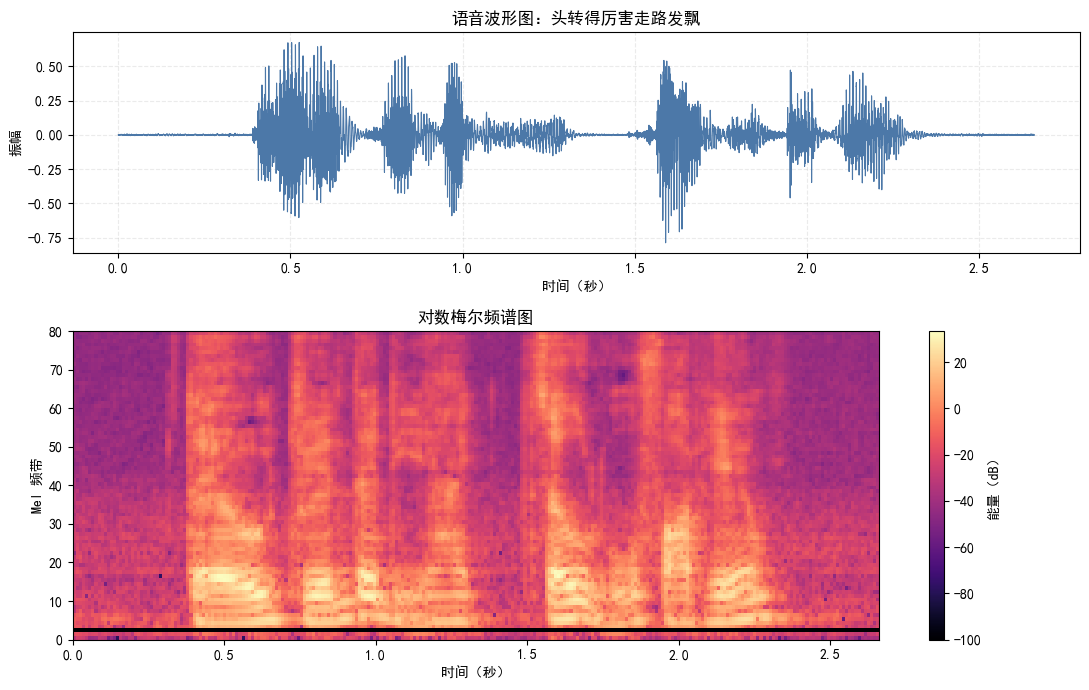

样本音频: d:\深度学习作业\课程设计(低资源衡阳方言语音识别系统)\asr-experiments\wav2vec2\static\分工\speaker_01\part\per\D\501-600\-71.wav
采样率: 16000 Hz，时长: 2.66 秒


In [25]:
# sample_prediction = predictions_df.sort_values("CER", ascending=False).iloc[0]
sample_prediction = predictions_df[predictions_df["CER"] == 0].iloc[0]
matched = valid_df[valid_df["sentence"].astype(str) == str(sample_prediction["GT"])]
if matched.empty:
    sample_row = valid_df.iloc[0]
    sample_text = sample_row["sentence"]
else:
    sample_row = matched.iloc[0]
    sample_text = sample_prediction["GT"]

audio_path = resolve_audio_path(sample_row["path"])
audio, sample_rate = read_wav_mono(audio_path)
duration = len(audio) / sample_rate
time_axis = np.arange(len(audio)) / sample_rate
mel_spec = log_mel_spectrogram(audio, sample_rate)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), gridspec_kw={"height_ratios": [1, 1.4]})
axes[0].plot(time_axis, audio, color="#4C78A8", linewidth=0.8)
axes[0].set_title(f"语音波形图：{sample_text}")
axes[0].set_xlabel("时间（秒）")
axes[0].set_ylabel("振幅")
axes[0].grid(alpha=0.25, linestyle="--")

image = axes[1].imshow(
    mel_spec,
    origin="lower",
    aspect="auto",
    cmap="magma",
    extent=[0, duration, 0, mel_spec.shape[0]],
)
axes[1].set_title("对数梅尔频谱图")
axes[1].set_xlabel("时间（秒）")
axes[1].set_ylabel("Mel 频带")
fig.colorbar(image, ax=axes[1], label="能量（dB）")
plt.tight_layout()
plt.show()

print(f"样本音频: {audio_path}")
print(f"采样率: {sample_rate} Hz，时长: {duration:.2f} 秒")

上方波形图反映了语音信号在时间维度上的振幅变化，可以看出该语音样本由多个发音片段组成，中间存在一定停顿，说明实际口语表达具有明显的节奏变化。下方对数梅尔频谱图展示了语音在不同时间和频率范围内的能量分布，亮色区域表示能量较强的发音部分，暗色区域则多对应静音或弱发音区域。

从频谱图可以看出，语音能量主要集中在低频和中频范围，不同发音片段在时间和频率维度上呈现出不同的能量模式。这说明模型需要同时学习语音的时间变化特征和频谱结构特征，才能完成从方言语音到文本序列的识别。该可视化结果也表明，自建衡阳方言语音数据中存在停顿、语速变化和发音强弱差异，这些因素会增加低资源方言语音识别任务的难度。

#### 6.5.2 CER 分布可视化

**样本级 CER 分布**  
以下代码绘制模型在验证集上的 CER 直方图和箱线图，用于观察大多数样本的识别误差范围以及少数高错误样本的分布情况。

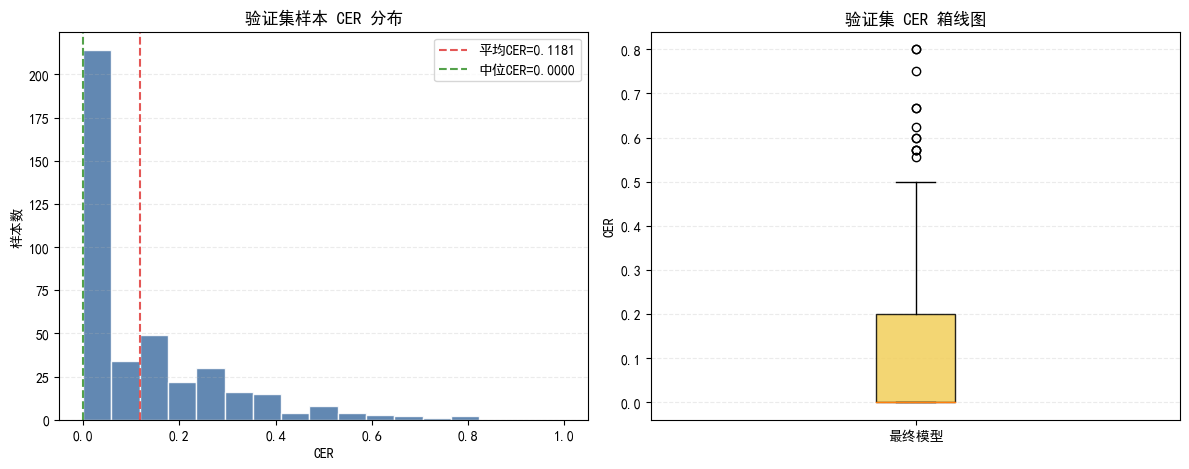

,指标,数值
0,样本数,404
1,平均 CER,0.1181
2,中位 CER,0.0000
3,P90 CER,0.3333
4,CER=0 占比,52.97%
5,CER≤0.2 占比,76.49%


In [22]:
cer_values = predictions_df["CER"].astype(float)
exact_match_rate = (cer_values == 0).mean()
cer_le_02_rate = (cer_values <= 0.2).mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
bins = np.linspace(0, max(1.0, cer_values.max()), 18)
axes[0].hist(cer_values, bins=bins, color="#4C78A8", edgecolor="white", alpha=0.88)
axes[0].axvline(cer_values.mean(), color="#E45756", linestyle="--", label=f"平均CER={cer_values.mean():.4f}")
axes[0].axvline(cer_values.median(), color="#54A24B", linestyle="--", label=f"中位CER={cer_values.median():.4f}")
axes[0].set_title("验证集样本 CER 分布")
axes[0].set_xlabel("CER")
axes[0].set_ylabel("样本数")
axes[0].grid(axis="y", alpha=0.25, linestyle="--")
axes[0].legend()

axes[1].boxplot(cer_values, vert=True, patch_artist=True, boxprops={"facecolor": "#F2CF5B", "alpha": 0.85})
axes[1].set_title("验证集 CER 箱线图")
axes[1].set_ylabel("CER")
axes[1].grid(axis="y", alpha=0.25, linestyle="--")
axes[1].set_xticklabels(["最终模型"])

plt.tight_layout()
plt.show()

cer_summary = pd.DataFrame([
    ["样本数", len(cer_values)],
    ["平均 CER", f"{cer_values.mean():.4f}"],
    ["中位 CER", f"{cer_values.median():.4f}"],
    ["P90 CER", f"{cer_values.quantile(0.9):.4f}"],
    ["CER=0 占比", f"{exact_match_rate:.2%}"],
    ["CER≤0.2 占比", f"{cer_le_02_rate:.2%}"],
], columns=["指标", "数值"])
display(cer_summary)

从验证集 CER 分布可以看出，最终模型在多数样本上取得了较低的字符错误率。404 条验证样本中，平均 CER 为 0.1181，中位 CER 为 0.0000，说明模型整体识别误差较低，并且至少一半样本能够实现完全正确识别。直方图中大量样本集中在 CER=0 附近，也进一步说明模型对多数衡阳方言语音具有较好的识别能力。

从箱线图可以看出，样本 CER 主要集中在较低区间，但仍存在少量高 CER 离群点，说明模型在个别语音样本上仍存在识别困难。结合统计结果，模型的完全匹配率达到 52.97%，CER≤0.2 的样本占比达到 76.49%，表明大多数样本的识别结果较为准确。P90 CER 为 0.3333，说明仍有约 10% 的样本错误率相对较高，后续可进一步针对发音模糊、语速较快、方言特征较强或音频质量较差的样本进行数据扩充和优化。

#### 6.5.3 错误样本分析

**高 CER 样本表格**  
以下代码选取验证集中 CER 较高的样本，展示真实文本、预测文本、CER 及主要错误类型，用于分析模型错误来源。

In [31]:
error_rows = []
for _, row in predictions_df.sort_values("CER", ascending=False).head(12).iterrows():
    counts = error_counts(row["GT"], row["PR"])
    error_rows.append({
        "真实文本": row["GT"],
        "预测文本": row["PR"],
        "CER": f"{row['CER']:.4f}",
        "文本长度": int(row["LEN"]),
        "替换数": counts["替换"],
        "删除数": counts["删除"],
        "插入数": counts["插入"],
        # "主要错误类型": classify_error(row),
    })

error_table = pd.DataFrame(error_rows)
display(error_table)

# error_type_counts = error_table["主要错误类型"].value_counts()
# fig, axis = plt.subplots(figsize=(8, 4.5))
# bars = axis.bar(error_type_counts.index, error_type_counts.values, color="#E45756", alpha=0.85)
# axis.set_title("高 CER 样本主要错误类型统计")
# axis.set_xlabel("错误类型")
# axis.set_ylabel("样本数")
# axis.grid(axis="y", alpha=0.25, linestyle="--")
# for bar, value in zip(bars, error_type_counts.values):
#     axis.text(bar.get_x() + bar.get_width() / 2, value, str(value), ha="center", va="bottom")
# plt.xticks(rotation=15)
# plt.tight_layout()
# plt.show()

,真实文本,预测文本,CER,文本长度,替换数,删除数,插入数
0,尿的时候疼,有尿时疼痛,0.8000,5,4,0,0
1,刚生完孩子,刚总了是结,0.8000,5,4,0,0
2,指头那里,急直头这里,0.7500,4,2,0,1
3,老人家,老睛干,0.6667,3,2,0,0
4,昨天晚上烧到将近三十九度,做晚上小了加正三是酒度,0.6667,12,7,1,0
5,光线强就睁不开眼,关上常就中不开痒,0.6250,8,5,0,0
6,担心是骨折,刚性是骨这,0.6000,5,3,0,0
7,家里人也有,家得能压有,0.6000,5,3,0,0
8,看东西变成两个,看东西变的变子两的,0.5714,7,2,0,2
9,老是往上冒酸味,老时晚上没酸微,0.5714,7,4,0,0


表中列出了验证集中 CER 较高的部分错误样本。可以看出，高错误样本主要集中在短句或发音相近的文本中。当真实文本较短时，少量字符识别错误也会导致 CER 明显升高，例如“老人家”仅包含 3 个字符，若出现 2 个字符替换，CER 就会达到 0.6667。整体来看，错误类型以字符替换为主，说明模型在部分方言发音、近音字符和口语短句上仍存在混淆。

此外，部分样本还存在插入或删除错误，可能与语速较快、停顿不明显、音频发音较弱或方言表达差异有关。该结果表明，虽然模型在多数样本上能够取得较低 CER，但对于短文本、发音模糊和方言特征较强的样本，仍需要通过扩充数据、提升标注质量和优化解码策略进一步改进。

#### 6.5.4 字符级错误统计

**ASR 版本的混淆分析**  
传统分类混淆矩阵不适合直接用于 ASR 变长序列输出。以下代码基于字符级编辑距离对齐，统计替换、删除和插入错误的高频字符，可作为语音识别任务中的字符级混淆分析。

高频替换错误：


,真实字符,预测字符,次数
0,是,时,4
1,痛,疼,3
2,又,还,3
3,近,正,2
4,味,微,2
5,讲,说,2
6,着,了,2
7,也,夜,2
8,喝,吃,2
9,背,白,2


高频删除错误：


,被漏识别字符,次数
0,有,3
1,又,3
2,也,2
3,昨,1
4,要,1
5,天,1
6,十,1
7,楚,1
8,孩,1
9,股,1


高频插入错误：


,被插入字符,次数
0,有,3
1,老,2
2,无,2
3,急,1
4,变,1
5,的,1
6,微,1
7,一,1
8,没,1
9,医,1


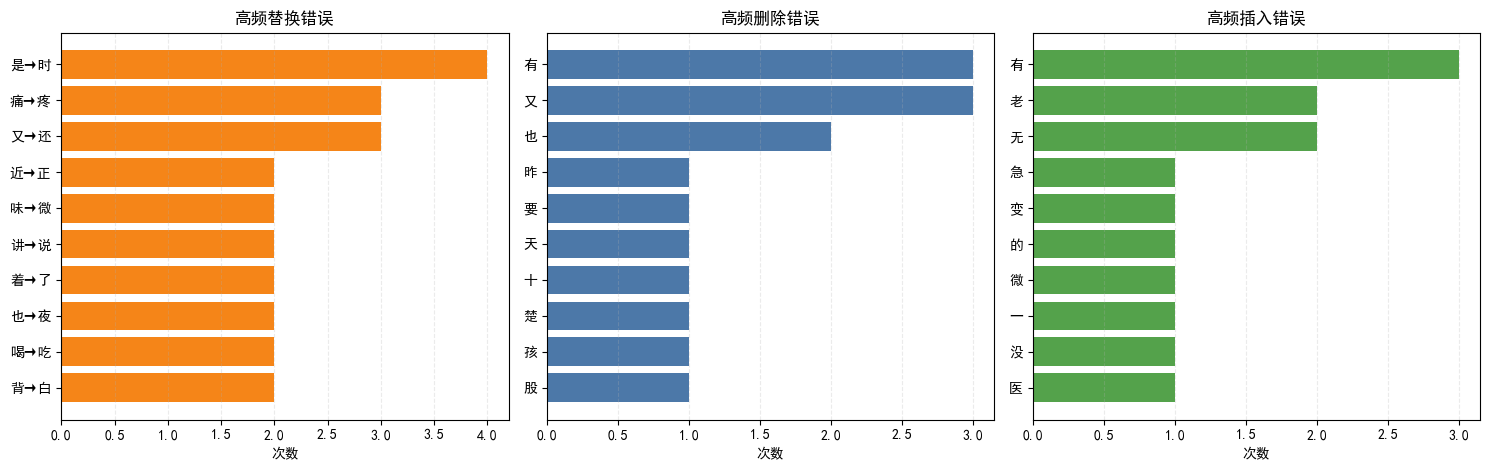

字符级错误总数：替换 283，删除 31，插入 29。


In [24]:
replace_counter = Counter()
delete_counter = Counter()
insert_counter = Counter()

for _, row in predictions_df.iterrows():
    for op, ref_char, hyp_char in align_chars(row["GT"], row["PR"]):
        if op == "replace":
            replace_counter[(ref_char, hyp_char)] += 1
        elif op == "delete":
            delete_counter[ref_char] += 1
        elif op == "insert":
            insert_counter[hyp_char] += 1

replace_table = pd.DataFrame(
    [{"真实字符": ref, "预测字符": hyp, "次数": count} for (ref, hyp), count in replace_counter.most_common(10)]
)
delete_table = pd.DataFrame(
    [{"被漏识别字符": char, "次数": count} for char, count in delete_counter.most_common(10)]
)
insert_table = pd.DataFrame(
    [{"被插入字符": char, "次数": count} for char, count in insert_counter.most_common(10)]
)

print("高频替换错误：")
display(replace_table)
print("高频删除错误：")
display(delete_table)
print("高频插入错误：")
display(insert_table)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

if not replace_table.empty:
    labels = replace_table["真实字符"] + "→" + replace_table["预测字符"]
    axes[0].barh(labels[::-1], replace_table["次数"][::-1], color="#F58518")
axes[0].set_title("高频替换错误")
axes[0].set_xlabel("次数")
axes[0].grid(axis="x", alpha=0.25, linestyle="--")

if not delete_table.empty:
    axes[1].barh(delete_table["被漏识别字符"][::-1], delete_table["次数"][::-1], color="#4C78A8")
axes[1].set_title("高频删除错误")
axes[1].set_xlabel("次数")
axes[1].grid(axis="x", alpha=0.25, linestyle="--")

if not insert_table.empty:
    axes[2].barh(insert_table["被插入字符"][::-1], insert_table["次数"][::-1], color="#54A24B")
axes[2].set_title("高频插入错误")
axes[2].set_xlabel("次数")
axes[2].grid(axis="x", alpha=0.25, linestyle="--")

plt.tight_layout()
plt.show()

total_replace = sum(replace_counter.values())
total_delete = sum(delete_counter.values())
total_insert = sum(insert_counter.values())
print(f"字符级错误总数：替换 {total_replace}，删除 {total_delete}，插入 {total_insert}。")

为进一步分析模型的错误来源，本文对验证集预测结果进行字符级编辑距离统计，并分别统计替换、删除和插入三类错误。结果显示，字符级错误总数中替换错误最多，共 283 次；删除错误为 31 次，插入错误为 29 次。

从高频替换错误可以看出，模型容易将部分发音相近或语义相近的字符混淆，例如“是”被识别为“时”，“痛”被识别为“疼”，“味”被识别为“微”，“讲”被识别为“说”等。这类错误与衡阳方言发音差异、口语表达习惯以及医疗场景短句中的近义词表达有关，说明模型在细粒度发音区分和上下文语义判断方面仍存在一定不足。

从删除和插入错误来看，高频错误字符主要集中在“有”“又”“也”“老”“无”等短字符或功能性表达上。这类字符在实际语音中可能存在发音较轻、时长较短或与前后字符连读的情况，因此模型在解码过程中容易出现漏识别或额外插入。总体来看，删除和插入错误数量明显少于替换错误，说明模型在语音序列与文本序列的整体对齐方面表现较稳定，但对短词、弱读词和方言口语细节仍需进一步优化。
